In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, ttest_ind

In [3]:
df = pd.read_csv('data.csv')
df.shape

(2240, 28)

In [4]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Show the first few rows of the DataFrame
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [6]:
# list the columns of the DataFrame
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

ID : Unique identifier for each customer 

Year_Birth : Year the customer was born --Discret

Education : Customer’s education level --Categorie

Marital_Status : Customer’s marital status --Categorie

Income : Yearly income of the customer --Continue

Kidhome : Number of young children in the household --Discret

Teenhome : Number of teenagers in the household --Discret

Dt_Customer : Date when the customer enrolled/joined the company --Discret

Recency : Number of days since the customer’s last purchase --Discret

MntWines : Amount spent on wine --Continue

MntFruits : Amount spent on fruits --Continue

MntMeatProducts : Amount spent on meat products --Continue

MntFishProducts : Amount spent on fish products --Continue

MntSweetProducts : Amount spent on sweet products --Continue

MntBakedProds : Amount spent on baked products --Continue

NumDealsPurchases : Number of purchases made with discounts --Discret

NumWebPurchases : Number of purchases made online --Discret

NumCatalogPurchases : Number of purchases made via catalog --Discret

NumStorePurchases : Number of purchases made in physical stores --Discret

NumWebVisitsMonth : Number of website visits per month --Discret

AcceptedCmp : if customer accepted campaign 1, 0 otherwise --Discret

Response : 1 if customer accepted the last campaign, 0 otherwise --Discret

Complain : 1 if customer complained, 0 otherwise --Discret

Country : Customer’s country --Categorie

In [7]:
# Get summary statistics for the DataFrame
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


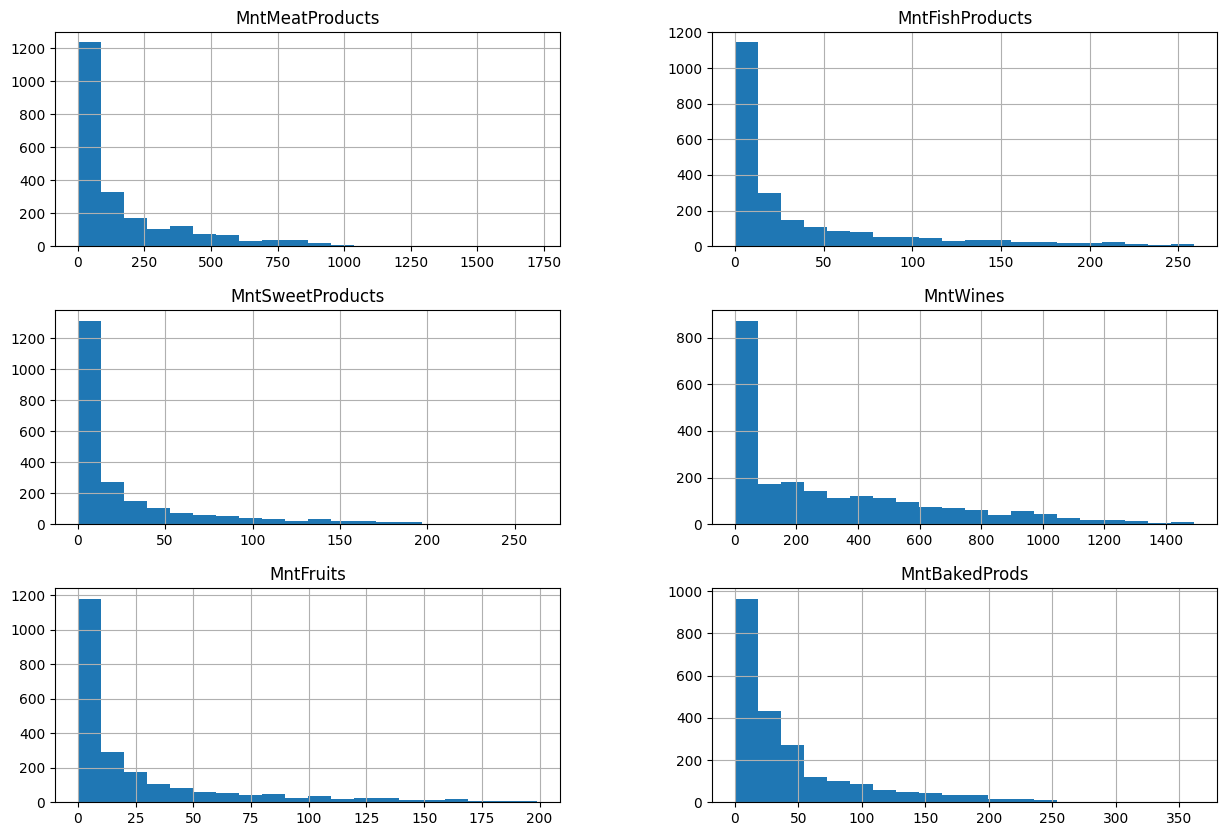

In [8]:
df[['MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntWines', 'MntFruits', 'MntBakedProds']].hist(bins=20, figsize=(15, 10))
plt.show()

<Axes: xlabel='Country', ylabel='None'>

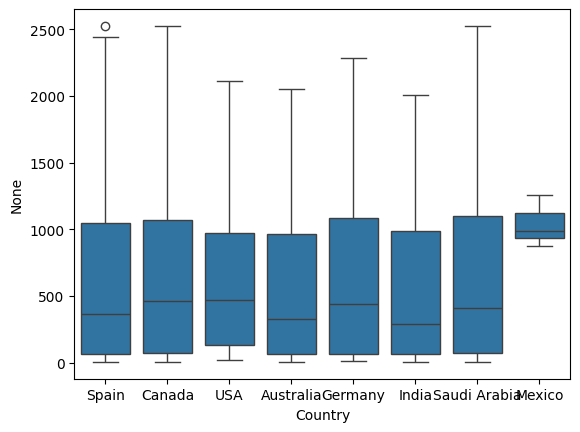

In [9]:
sns.boxplot( x='Country', y=df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntWines']+df['MntFruits']+df['MntBakedProds'], data=df)


In [10]:
df['total_spent'] = df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntWines'] + df['MntFruits'] + df['MntBakedProds']
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,total_spent
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,1,0,0,0,0,0,1,0,Spain,1190
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,5,0,0,0,0,1,1,0,Canada,577
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,2,0,0,0,0,0,0,0,USA,251
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,7,0,0,0,0,0,0,0,Australia,11
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,7,1,0,0,0,0,1,0,Spain,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,4,0,0,0,0,0,0,0,USA,689
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,8,0,0,0,0,0,0,0,Spain,55
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,8,0,0,0,0,0,0,0,Spain,309
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,3,0,0,0,0,0,0,0,India,1383


<Axes: title={'center': 'Total Amount Spent by Country'}, xlabel='Country'>

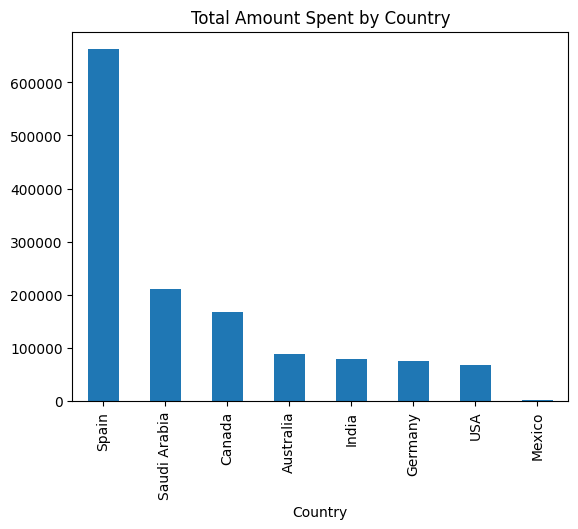

In [11]:
df_gc = df.groupby('Country')[['total_spent']].sum().sort_values(by='total_spent', ascending=False)
df_gc['total_spent'].plot(kind='bar', title='Total Amount Spent by Country')

<Axes: >

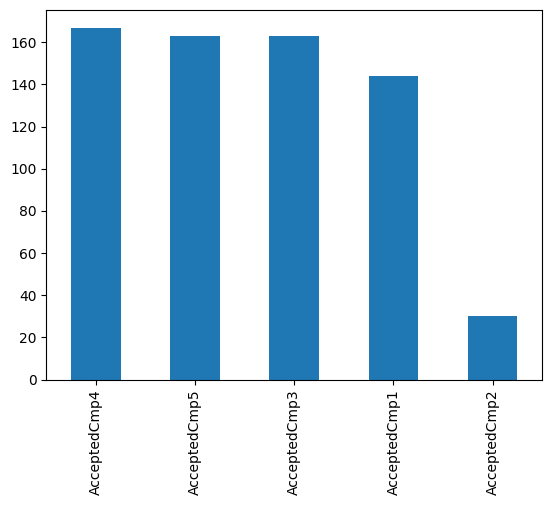

In [12]:
# Sum up all the 1s in each column and plot
df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum().sort_values(ascending=False).plot(kind='bar')

In [13]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,total_spent
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,1,0,0,0,0,0,1,0,Spain,1190
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,5,0,0,0,0,1,1,0,Canada,577
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,2,0,0,0,0,0,0,0,USA,251
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,7,0,0,0,0,0,0,0,Australia,11
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,7,1,0,0,0,0,1,0,Spain,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,4,0,0,0,0,0,0,0,USA,689
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,8,0,0,0,0,0,0,0,Spain,55
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,8,0,0,0,0,0,0,0,Spain,309
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,3,0,0,0,0,0,0,0,India,1383


<Axes: xlabel=' Income ', ylabel='total_spent'>

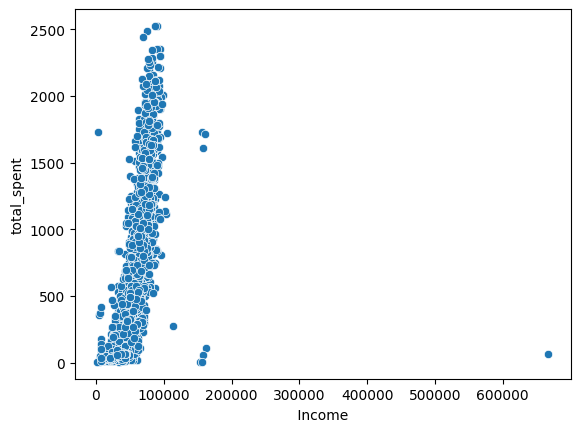

In [14]:
sns.scatterplot(y='total_spent', x=' Income ', data=df)

H0 : The variable ' Income ' and 'total_spent' are not correlated

In [15]:
df_clean = df[[' Income ', 'total_spent']].dropna()
corr, p = pearsonr(df_clean[' Income '], df_clean['total_spent'])

print(corr)

0.6675760903888283


The based on our correlation test we notice that there is a strong correlation between the two variables

In [16]:
print(p)

5.843958806403454e-286


The p value is extreemely close to zero P = 5.84e-286 < 0.05, therefore we reject H0 hypothesis, and based on the correlation cofficient r = 0.66 the two value are strongly correlated positively

<Axes: xlabel='AcceptedCmp1'>

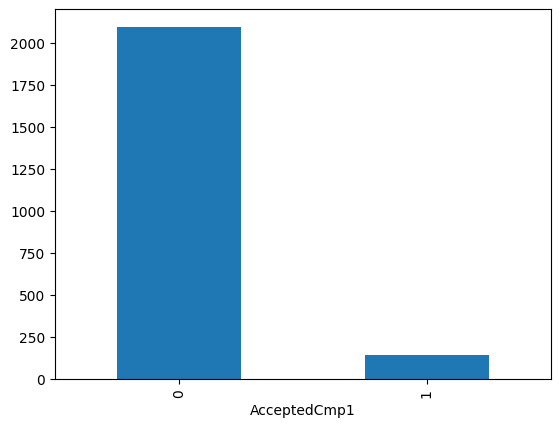

In [17]:
df['AcceptedCmp1'].value_counts().plot(kind='bar')

<Axes: xlabel='AcceptedCmp1', ylabel='total_spent'>

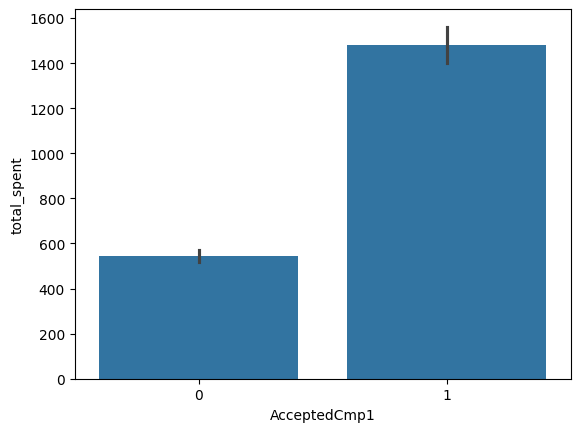

In [18]:
sns.barplot(x='AcceptedCmp1', y='total_spent', data=df)

H0 : The average total_spent is the same for customers with accepted campaign 1 and those who don't

In [19]:
stat, p = ttest_ind(df[df['AcceptedCmp1'] == 1]['total_spent'], df[df['AcceptedCmp1'] == 0]['total_spent'], equal_var=False)
print(stat, p)

21.279565568730288 1.5515667359182744e-49


the p value is very close to 0 p = 1.55e-49 < 0.05 therefore we can reject H0